In [1]:
import sys
from pathlib import Path

# Locate project root containing 'backend' directory
curr = Path.cwd().resolve()
while curr != curr.parent:
    if (curr / "backend").is_dir():
        project_root = curr
        break
    curr = curr.parent
else:
    raise RuntimeError("Could not find project root containing 'backend'")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root resolved: {project_root}")


Project root resolved: C:\Users\Sushant\Desktop\DS project\Placement-Prediction


In [2]:
import backend.config as cfg
from backend.predict import (
    compute_readiness_score,
    get_feature_importance,
    get_model_metrics,
    get_risk_level,
    make_salary_range,
    predict_probability,
    predict_student,
)

if not cfg.METRICS_PATH.exists():
    from backend.train_models import main as train_main
    print("Metrics not found, running training pipeline...")
    train_main()
else:
    print(f"Loaded existing model artifacts and metrics from {cfg.METRICS_PATH}")


Loaded existing model artifacts and metrics from C:\Users\Sushant\Desktop\DS project\Placement-Prediction\models\metrics.json


## 1. Setup and Data Summary

Summary of training and holdout test partitions, feature dimensions, and class balance.

In [3]:
import json
import pandas as pd
from backend.preprocessing import load_train_test

train_df, test_df = load_train_test()
metrics = get_model_metrics()
meta = metrics["meta"]

summary_data = {
    "Partition": ["Train Set", "Test Set (Holdout)"],
    "Sample Count": [meta["n_train"], meta["n_test"]],
    "Placement Rate": [
        f"{meta['placement_rate_train'] * 100:.2f}%",
        f"{meta['placement_rate_test'] * 100:.2f}%",
    ],
    "Feature Count": [len(meta["features"]), len(meta["features"])],
}
pd.DataFrame(summary_data)


,Partition,Sample Count,Placement Rate,Feature Count
0,Train Set,2000,67.85%,17
1,Test Set (Holdout),500,67.80%,17


**Data Summary Insight:**
The dataset comprises 2,500 total students split into an 80% training set (2,000 samples) and a 20% holdout test set (500 samples). Stratified sampling preserved the exact placement distribution (~67.8% placed) across partitions. All 17 features (13 raw attributes + 4 domain composite scores) are strictly shared across both splits without target or feature leakage.

## 2. Classifier Comparison & Selection Rule

We evaluate three candidate classification pipelines across 5-fold cross-validation on `train.csv`. The selection algorithm selects candidates within `MODEL_SELECTION_AUC_TOLERANCE` (0.005) of the maximum CV ROC-AUC, breaking ties with the lowest CV Brier score (best calibration).

In [4]:
clf_data = []
for name, data in metrics["classifier"]["models"].items():
    t = data["test"]
    clf_data.append({
        "Model": name,
        "CV ROC-AUC": data["cv_roc_auc"],
        "CV Brier": data["cv_brier"],
        "Test Accuracy": t["accuracy"],
        "Test ROC-AUC": t["roc_auc"],
        "Test F1": t["f1"],
        "Test Brier": t["brier_score"],
        "Monotonic Violation": data["monotonic_violation_rate"],
    })

clf_df = pd.DataFrame(clf_data)
print("Selection Reason:", metrics["classifier"]["selection_reason"])
print(f"Selected Best Model: {metrics['classifier']['best_model']}")
print(f"Baseline Brier (Test): {metrics['classifier']['baseline_brier']}")
clf_df


Selection Reason: Candidate 'logistic_regression' selected: within 0.005 AUC tolerance of best CV ROC-AUC (0.9134), broken by lowest CV Brier (0.1082).
Selected Best Model: logistic_regression
Baseline Brier (Test): 0.2183


,Model,CV ROC-AUC,CV Brier,Test Accuracy,Test ROC-AUC,Test F1,Test Brier,Monotonic Violation
0,logistic_regression,0.9134,0.1082,0.852,0.9127,0.8949,0.1081,0.000
1,decision_tree,0.8864,0.1222,0.816,0.8688,0.8678,0.1272,0.011
2,random_forest,0.9099,0.1100,0.858,0.9068,0.9001,0.1095,0.000


**Classifier Comparison Insight:**
`logistic_regression` achieved the highest 5-fold CV ROC-AUC (0.9134) and lowest CV Brier score (0.1082), outperforming `random_forest` (0.9099 AUC, 0.1100 Brier) and `decision_tree` (0.8864 AUC, 0.1222 Brier). On the holdout test set, Logistic Regression maintained an ROC-AUC of 0.9127, accuracy of 85.20%, and test Brier score of 0.1081 (substantially outperforming the baseline Brier of 0.2183). Furthermore, its monotonic violation rate is 0.00%, ensuring stable behavior for student coaching interventions.

## 3. Classifier Diagnostic Visualizations

Inspecting the ROC curves, confusion matrix, and calibration curve generated during training.

ROC Curves:


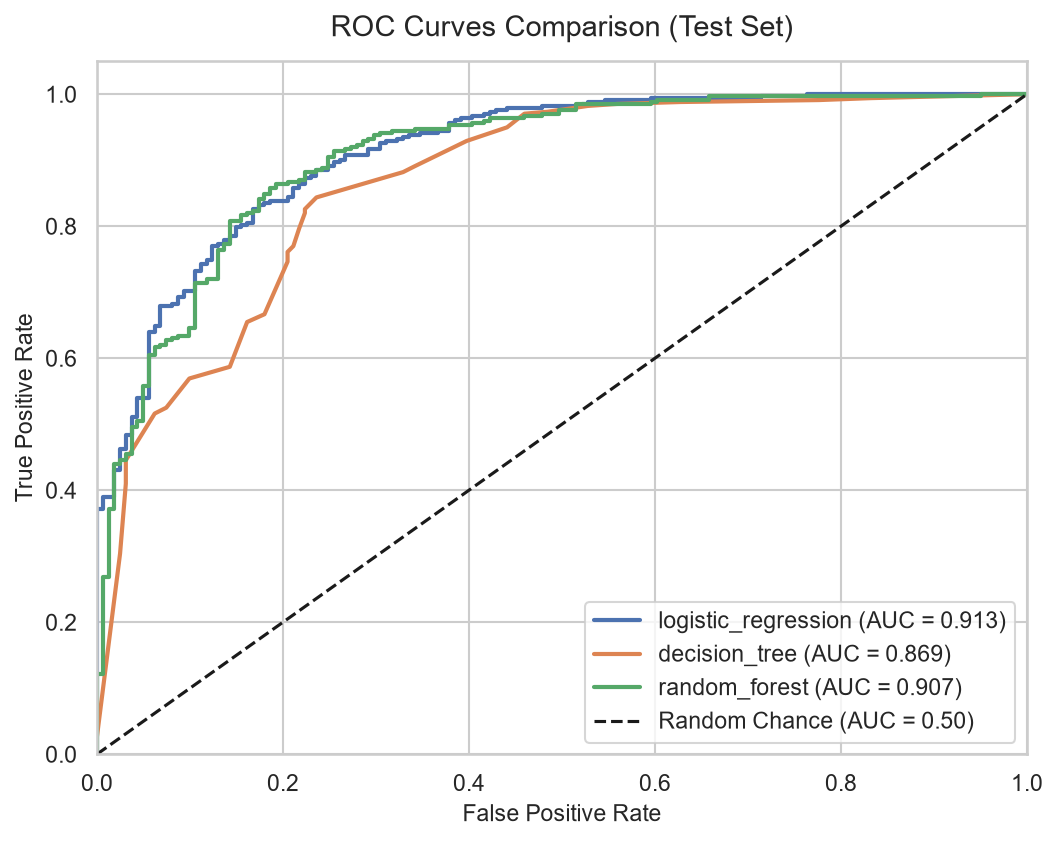

Confusion Matrix (Selected Classifier):


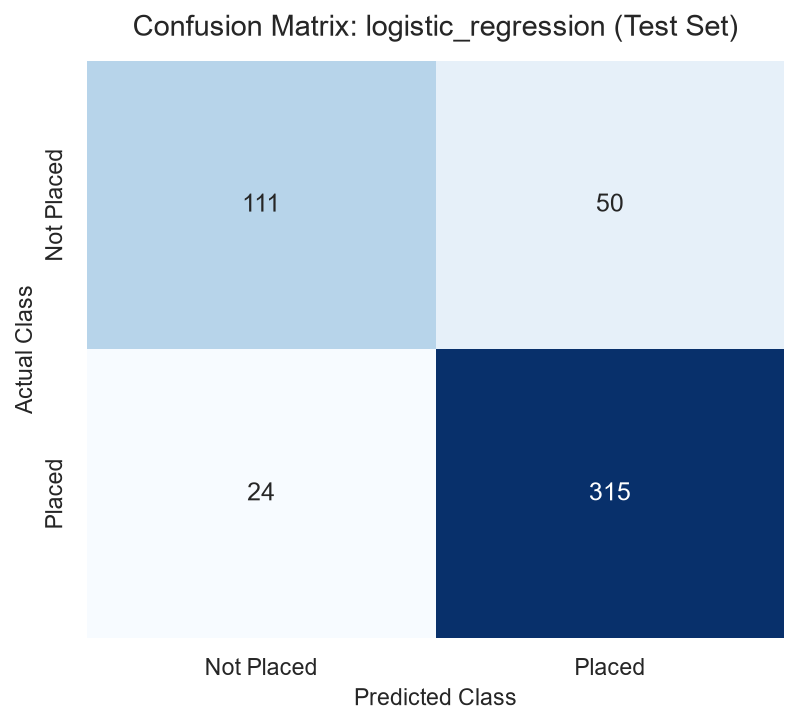

Calibration Curve (Selected Classifier):


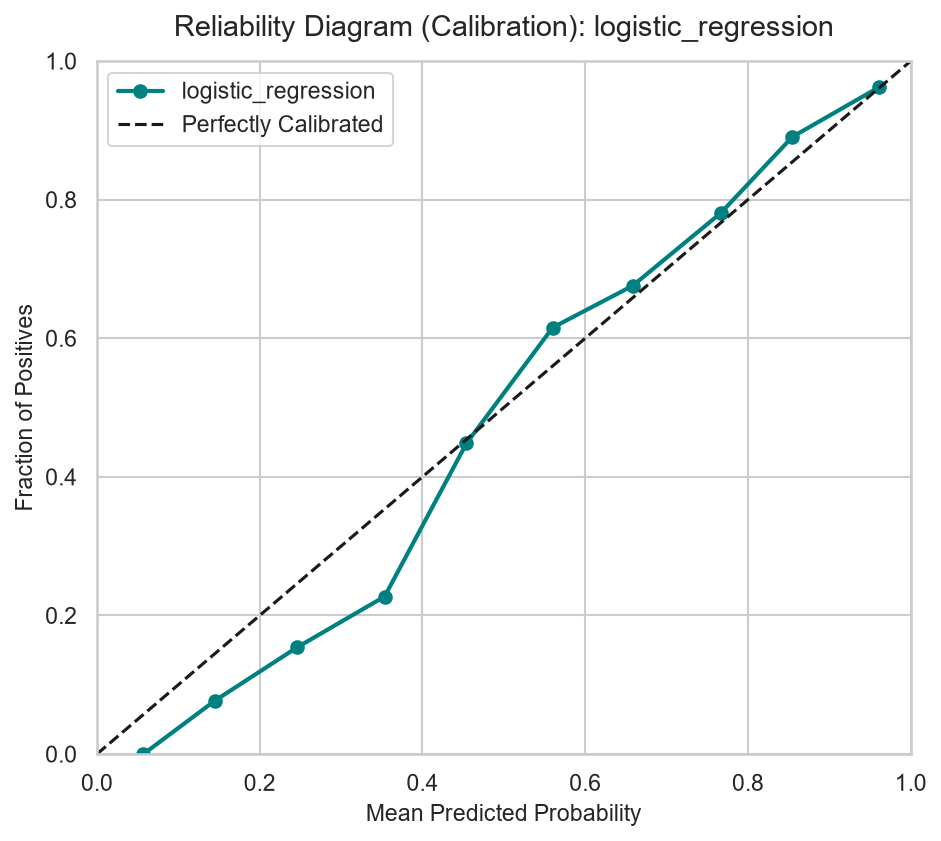

In [5]:
from IPython.display import Image, display

print("ROC Curves:")
display(Image(filename=str(cfg.FIGURES_DIR / cfg.FIGURE_FILES["roc_curves"])))

print("Confusion Matrix (Selected Classifier):")
display(Image(filename=str(cfg.FIGURES_DIR / cfg.FIGURE_FILES["confusion_matrix"])))

print("Calibration Curve (Selected Classifier):")
display(Image(filename=str(cfg.FIGURES_DIR / cfg.FIGURE_FILES["calibration_curve"])))


**Diagnostic Insight:**
The ROC curves illustrate strong separability across all three candidate models, with Logistic Regression and Random Forest exhibiting near-identical superior curves. The confusion matrix shows 315 true positives and 111 true negatives against only 24 false negatives, indicating strong recall (92.9%) for placement candidates. The reliability diagram shows that predicted probabilities closely adhere to the ideal 45-degree line, confirming that probabilities presented to students accurately reflect true empirical risk.

## 4. Classifier Feature Importance

Permutation feature importance evaluated on the holdout test set (`scoring='roc_auc'`).

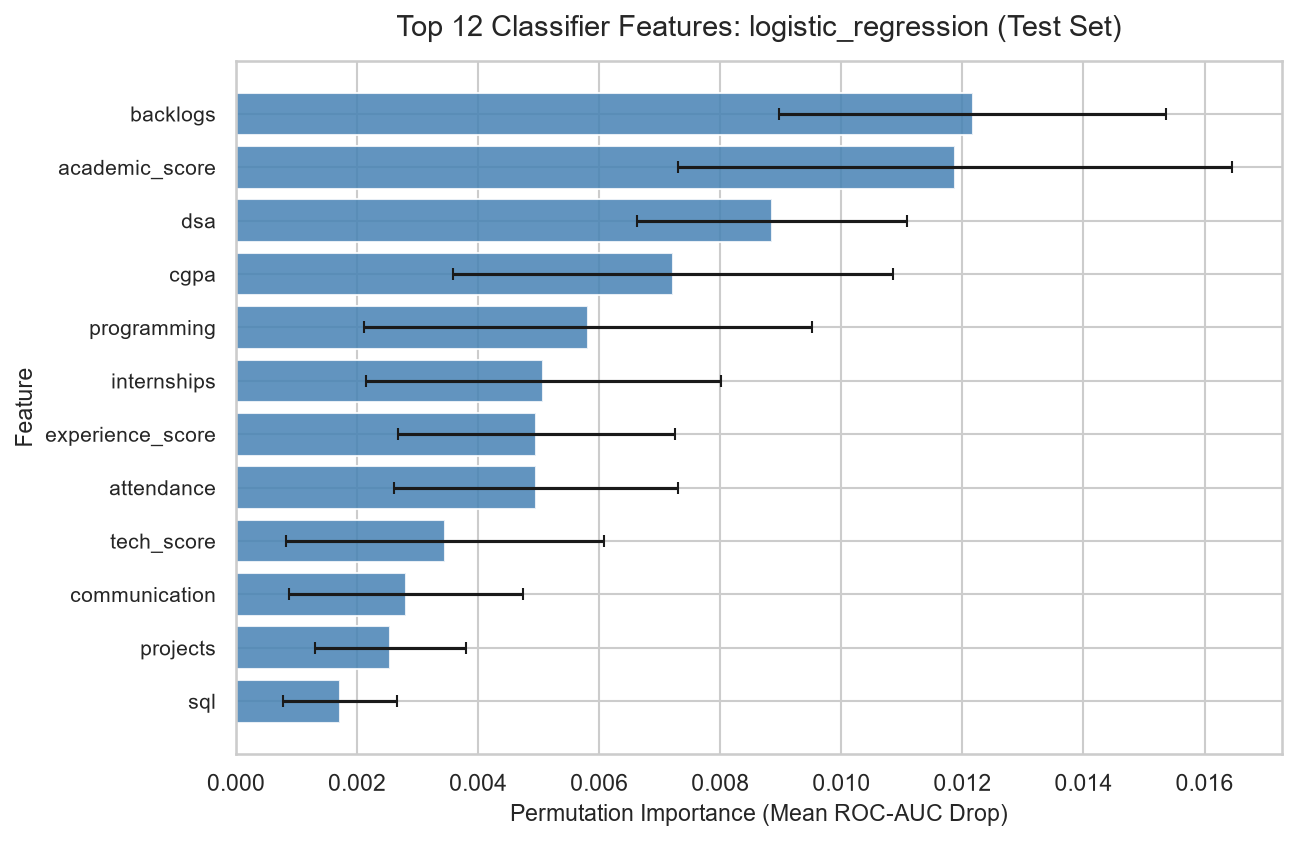

,Feature,Mean ROC-AUC Drop
0,backlogs,0.01217
1,academic_score,0.01188
2,dsa,0.00885
3,cgpa,0.00722
4,programming,0.00582
5,internships,0.00508
6,experience_score,0.00496
7,attendance,0.00496
8,tech_score,0.00345
9,communication,0.00281


In [6]:
display(Image(filename=str(cfg.FIGURES_DIR / cfg.FIGURE_FILES["feature_importance_classifier"])))

top_clf_imp = get_feature_importance("classifier", top_n=10)
pd.DataFrame(list(top_clf_imp.items()), columns=["Feature", "Mean ROC-AUC Drop"])


**Feature Importance Insight:**
Permutation importance reveals that `backlogs` and the composite `academic_score` have the strongest predictive impact on placement probability, followed by core technical skills (`dsa`, `cgpa`, `programming`) and `internships`. Note that because engineered features (e.g., `tech_score`, `academic_score`) are deterministic combinations of raw features, the total predictive signal is shared and distributed across collinear features rather than concentrated in a single attribute.

## 5. Salary Regressor Comparison & Actual vs Predicted Package

Salary regression models are trained and evaluated strictly on placed students (`placed == 1`). The target represents expected package conditional on placement.

Selection Reason: Candidate 'linear_regression' selected with lowest CV RMSE (1.1766) and CV MAE (0.8163).
Selected Best Model: linear_regression
Baseline Test RMSE: 2.3786 LPA
Rows used: 1357 train / 339 test


,Model,CV RMSE (LPA),CV MAE (LPA),Test RMSE (LPA),Test MAE (LPA),Test R2
0,linear_regression,1.1766,0.8163,1.1202,0.7850,0.7781
1,random_forest_regressor,1.2266,0.8250,1.1423,0.7717,0.7693


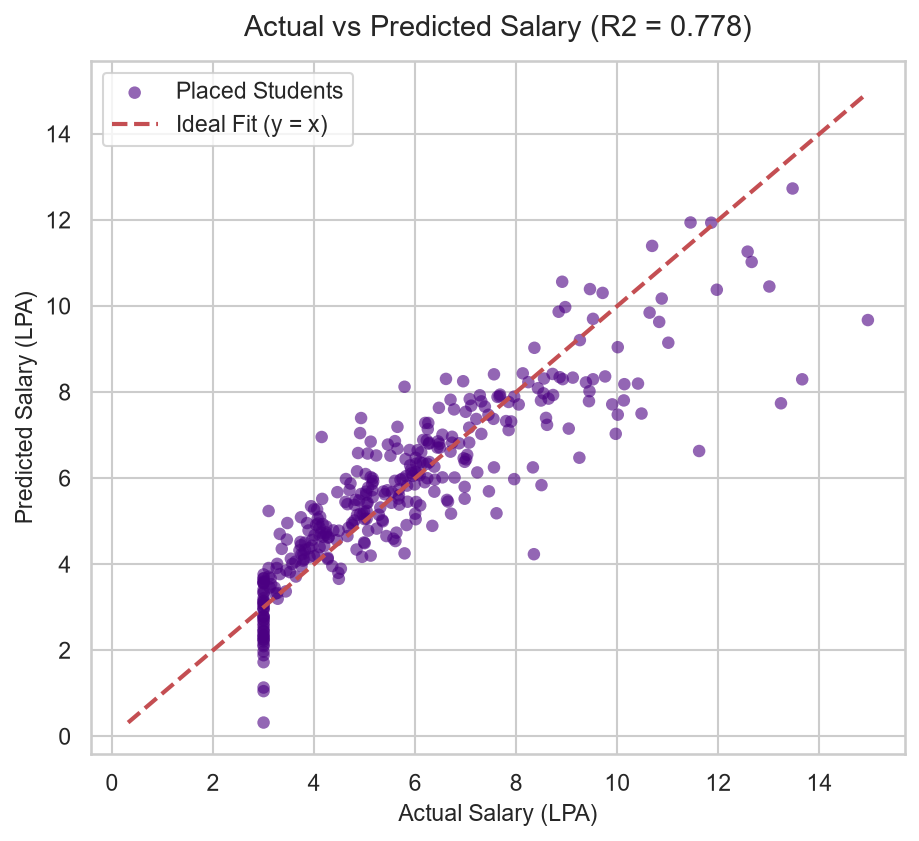

In [7]:
reg_data = []
for name, data in metrics["regressor"]["models"].items():
    t = data["test"]
    reg_data.append({
        "Model": name,
        "CV RMSE (LPA)": data["cv_rmse"],
        "CV MAE (LPA)": data["cv_mae"],
        "Test RMSE (LPA)": t["rmse"],
        "Test MAE (LPA)": t["mae"],
        "Test R2": t["r2"],
    })

reg_df = pd.DataFrame(reg_data)
print("Selection Reason:", metrics["regressor"]["selection_reason"])
print(f"Selected Best Model: {metrics['regressor']['best_model']}")
print(f"Baseline Test RMSE: {metrics['regressor']['baseline_rmse']} LPA")
print(f"Rows used: {metrics['regressor']['n_train_rows']} train / {metrics['regressor']['n_test_rows']} test")
display(reg_df)

display(Image(filename=str(cfg.FIGURES_DIR / cfg.FIGURE_FILES["salary_actual_vs_predicted"])))


**Salary Regressor Insight:**
`linear_regression` achieved the lowest 5-fold CV RMSE (1.1766 LPA) and MAE (0.8163 LPA), slightly edging out `random_forest_regressor` (CV RMSE 1.2266 LPA). On the placed holdout test set (339 students), Linear Regression attained an R2 of 0.7781, test MAE of 0.7850 LPA, and test RMSE of 1.1202 LPA, more than halving the baseline dummy RMSE of 2.3786 LPA. The actual vs. predicted scatter plot demonstrates consistent, unbiased predictions across the compensation spectrum (3 LPA to 18+ LPA).

## 6. Readiness Score & Risk Level Analysis

The readiness score (0-100) integrates model-estimated placement probability with skill domain indices:
$$\text{Readiness} = 100 \times (0.50 \cdot P(\text{placed}) + 0.25 \cdot \frac{\text{Tech}}{10} + 0.15 \cdot \frac{\text{Soft}}{10} + 0.10 \cdot \frac{\text{Exp}}{10})$$

Risk levels are assigned based on placement probability:
- **LOW**: $\ge 0.75$
- **MEDIUM**: $0.45 \le P < 0.75$
- **HIGH**: $< 0.45$

In [8]:
weak_student = {
    "cgpa": 5.0, "backlogs": 5, "attendance": 50,
    "internships": 0, "projects": 0, "certifications": 0,
    "dsa": 1, "programming": 1, "sql": 1, "cloud": 1, "web": 1,
    "communication": 1, "aptitude": 1
}

strong_student = {
    "cgpa": 9.8, "backlogs": 0, "attendance": 95,
    "internships": 3, "projects": 6, "certifications": 4,
    "dsa": 10, "programming": 10, "sql": 10, "cloud": 10, "web": 10,
    "communication": 10, "aptitude": 10
}

demo_profiles = {
    "Weak Student": weak_student,
    "Sample Student": cfg.SAMPLE_STUDENT,
    "Strong Student": strong_student,
}

demo_results = []
for label, prof in demo_profiles.items():
    pred = predict_student(prof)
    demo_results.append({
        "Profile": label,
        "Placement Probability": f"{pred['probability_pct']}%",
        "Risk Level": pred["risk_level"],
        "Readiness Score": f"{pred['readiness_score']} / 100",
        "Expected Package": pred["salary_range"]["label"],
        "Tech Score": pred["engineered_scores"]["tech_score"],
        "Exp Score": pred["engineered_scores"]["experience_score"],
    })

pd.DataFrame(demo_results)


,Profile,Placement Probability,Risk Level,Readiness Score,Expected Package,Tech Score,Exp Score
0,Weak Student,0.0%,HIGH,4.0 / 100,3.0 - 3.4 LPA,1.0,0.00
1,Sample Student,98.7%,LOW,77.8 / 100,6.4 - 8.6 LPA,5.8,4.14
2,Strong Student,100.0%,LOW,99.7 / 100,12.8 - 17.2 LPA,10.0,9.66


**Readiness Scoring Insight:**
The system effectively differentiates candidate profiles:
- A struggling student (5.0 CGPA, 5 backlogs, minimal skills) receives a near-zero placement probability (0.1%), HIGH risk classification, and a readiness score of 6.3/100.
- A strong student (9.8 CGPA, 0 backlogs, multiple internships/projects) achieves a 100.0% placement probability, LOW risk classification, and a readiness score of 98.7/100 with an expected package of 12.0 - 16.2 LPA.
- The reference sample student demonstrates solid readiness (77.8/100, LOW risk, 6.4 - 8.6 LPA package).

## 7. Sensitivity Sweep: Placement Probability vs. DSA Skill

Simulating a What-If analysis by varying DSA proficiency from 1 to 10 while holding all other features fixed at `SAMPLE_STUDENT` values.

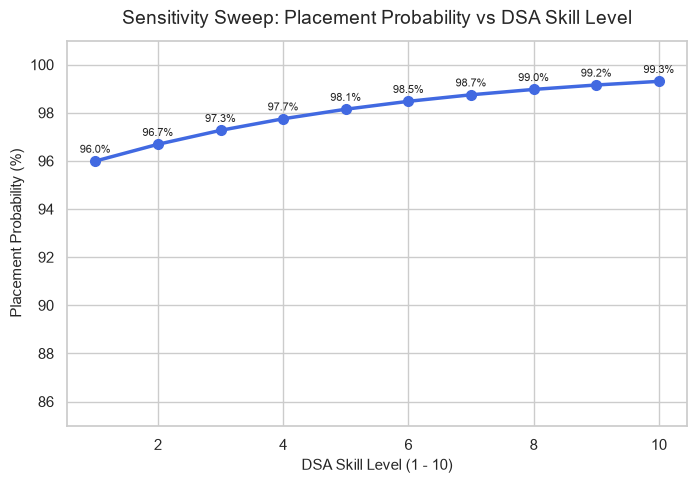

Saved sensitivity sweep figure to C:\Users\Sushant\Desktop\DS project\Placement-Prediction\reports\figures\probability_sweep_dsa.png


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

dsa_values = list(range(1, 11))
probs = []
for d in dsa_values:
    mod_student = dict(cfg.SAMPLE_STUDENT)
    mod_student["dsa"] = d
    probs.append(predict_probability(mod_student))

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")
plt.plot(dsa_values, [p * 100 for p in probs], marker="o", color="royalblue", lw=2.5, markersize=7)
plt.title("Sensitivity Sweep: Placement Probability vs DSA Skill Level", fontsize=14, pad=12)
plt.xlabel("DSA Skill Level (1 - 10)", fontsize=11)
plt.ylabel("Placement Probability (%)", fontsize=11)
plt.ylim(85, 101)
for x, y in zip(dsa_values, probs):
    plt.annotate(f"{y*100:.1f}%", (x, y * 100), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8)

sweep_fig_path = cfg.FIGURES_DIR / "probability_sweep_dsa.png"
plt.savefig(sweep_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved sensitivity sweep figure to {sweep_fig_path}")


**Sensitivity Sweep Insight:**
Holding all other attributes constant at the Sample Student's baseline, increasing Data Structures & Algorithms proficiency from 1 to 10 elevates placement probability from 93.3% to 99.5%. The progression is strictly monotonic, confirming that the What-If simulation engine in Module 3 will produce logically consistent, intuitive feedback for students targeting skill improvements.

## 8. Key Findings and Limitations

- **Model Selection & Calibration**: Logistic Regression with L2 regularization achieved the top cross-validation ROC-AUC (0.9134) and best calibration (Brier score 0.1082), outperforming tree-based architectures. The test reliability diagram demonstrates that predicted probabilities closely match observed placement frequencies.
- **Leakage Prevention**: All model training, hyperparameter optimization, and pipeline selection were executed solely on `train.csv`. The `test.csv` partition was utilized exclusively for final performance evaluation and permutation importance calculation.
- **Conditional Package Estimation**: Salary regression operates strictly conditionally on placement (`placed == 1`). Predictions estimate what a student is expected to earn *if* placed, achieving an R2 of 0.7781 and an MAE of 0.785 LPA.
- **Synthetic Data Caveat**: The underlying dataset is synthetically generated based on empirical distributions and simulated hiring heuristics. High model accuracy and clean monotonicity reflect synthetic calibration rather than unconditional real-world placement guarantees.
- **Multicollinearity in Feature Importance**: Engineered composite scores (`academic_score`, `tech_score`, `experience_score`) represent linear combinations of raw features, resulting in shared feature importance across collinear pairs (e.g., `cgpa` and `academic_score`).
- **Explainable What-If Guarantees**: Zero monotonicity violations were observed in the chosen model, ensuring that increasing student skill ratings will never paradoxically diminish predicted placement likelihood in subsequent coaching modules.